In [10]:
pip install numpy pandas matplotlib scikit-learn statsmodels xgboost torch


Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ CUDA GPU not available. Running on CPU.")

PyTorch version: 2.5.1
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [13]:
from pathlib import Path

data_path = Path(
    r"E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly"
)

csv_files = list(data_path.rglob("*.csv"))

print("CSV files found:", len(csv_files))

CSV files found: 80


In [14]:
data_list = []
empty_files = []
failed_files = []

for file in csv_files:

    try:

        # Skip physically empty files
        if os.path.getsize(file) == 0:
            empty_files.append(str(file))
            continue

        temp = pd.read_csv(file)

        # Skip files without data
        if temp.empty or len(temp.columns) == 0:
            empty_files.append(str(file))
            continue

        data_list.append(temp)

    except Exception as e:
        failed_files.append((str(file), str(e)))

print("Valid files:", len(data_list))
print("Empty files:", len(empty_files))
print("Failed files:", len(failed_files))

if len(data_list) == 0:
    raise ValueError("No valid CSV files found!")

df = pd.concat(data_list, ignore_index=True)

print("Combined shape:", df.shape)
display(df.head())

Valid files: 37
Empty files: 0
Failed files: 43
Combined shape: (455, 4)


,datetime,soil_moisture,year,month
0,2020-01-16 00:00:00,0.159529,2020,1
1,2020-01-18 00:00:00,0.232465,2020,1
2,2020-01-19 00:00:00,0.259042,2020,1
3,2020-01-21 00:00:00,0.250641,2020,1
4,2020-01-24 00:00:00,0.271695,2020,1


In [15]:
print(df.columns.tolist())

['datetime', 'soil_moisture', 'year', 'month']


In [16]:
# Convert datetime
df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce"
)

# Convert soil moisture to numeric
df["soil_moisture"] = pd.to_numeric(
    df["soil_moisture"],
    errors="coerce"
)

# Remove invalid values
df = df.dropna(
    subset=["datetime", "soil_moisture"]
)

# Remove infinity
df = df[
    np.isfinite(df["soil_moisture"])
]

# Remove negative values
df.loc[
    df["soil_moisture"] < 0,
    "soil_moisture"
] = 0

# Sort
df = df.sort_values("datetime")

# Remove duplicate timestamps
df = df.drop_duplicates(
    subset=["datetime"]
)

df = df.reset_index(drop=True)

print("Cleaned shape:", df.shape)

display(df.head())

Cleaned shape: (455, 4)


,datetime,soil_moisture,year,month
0,2020-01-16,0.159529,2020,1
1,2020-01-18,0.232465,2020,1
2,2020-01-19,0.259042,2020,1
3,2020-01-21,0.250641,2020,1
4,2020-01-24,0.271695,2020,1


In [17]:
print("Minimum:", df["soil_moisture"].min())
print("Maximum:", df["soil_moisture"].max())
print("Mean:", df["soil_moisture"].mean())
print("Median:", df["soil_moisture"].median())

display(df["soil_moisture"].describe())

Minimum: 0.1321814162656665
Maximum: 0.5105346544461102
Mean: 0.26329657150906455
Median: 0.2551618037045811


count    455.000000
mean       0.263297
std        0.058113
min        0.132181
25%        0.219660
50%        0.255162
75%        0.308983
max        0.510535
Name: soil_moisture, dtype: float64

In [18]:
df_daily = (
    df.set_index("datetime")["soil_moisture"]
      .resample("D")
      .mean()
      .to_frame()
)

print("Daily data:", df_daily.shape)

display(df_daily.head(15))

Daily data: (1396, 1)


,soil_moisture
datetime,
2020-01-16,0.159529
2020-01-17,NaN
2020-01-18,0.232465
2020-01-19,0.259042
2020-01-20,NaN
2020-01-21,0.250641
2020-01-22,NaN
2020-01-23,NaN
2020-01-24,0.271695


In [19]:
df_daily["soil_moisture"] = (
    df_daily["soil_moisture"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

print(
    "Missing values:",
    df_daily["soil_moisture"].isna().sum()
)

Missing values: 0


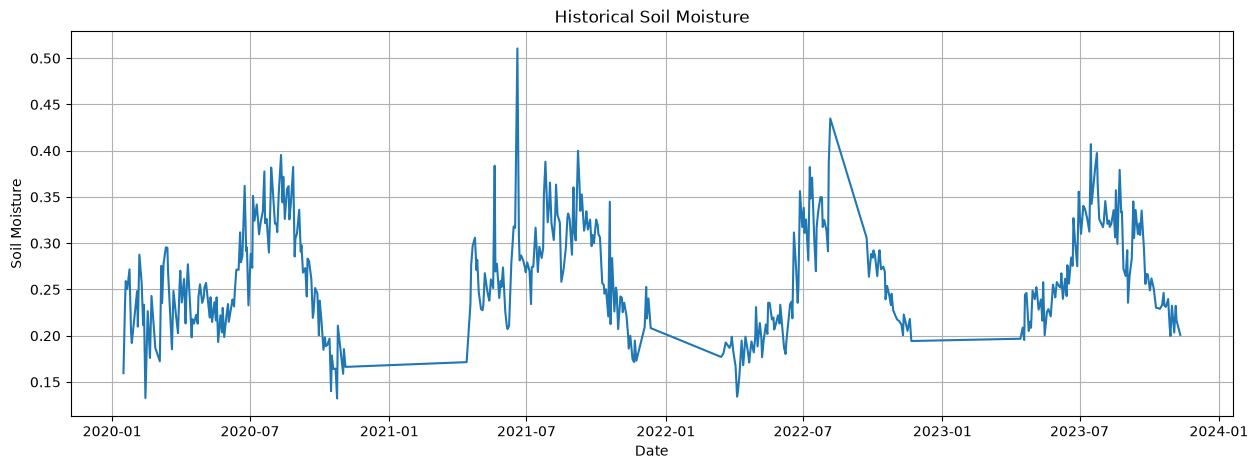

In [20]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_daily.index,
    df_daily["soil_moisture"]
)

plt.title("Historical Soil Moisture")
plt.xlabel("Date")
plt.ylabel("Soil Moisture")
plt.grid(True)

plt.show()

In [21]:
values = df_daily["soil_moisture"].values

split_index = int(len(values) * 0.80)

train = values[:split_index]
test = values[split_index:]

train_dates = df_daily.index[:split_index]
test_dates = df_daily.index[split_index:]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 1116
Testing samples: 280


In [22]:
def calculate_metrics(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mask = (
        np.isfinite(actual) &
        np.isfinite(predicted)
    )

    actual = actual[mask]
    predicted = predicted[mask]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    non_zero = actual != 0

    if np.sum(non_zero) > 0:
        mape = np.mean(
            np.abs(
                (actual[non_zero] - predicted[non_zero])
                / actual[non_zero]
            )
        ) * 100
    else:
        mape = np.nan

    r2 = r2_score(
        actual,
        predicted
    )

    return mae, rmse, mape, r2

In [23]:
print("Training ARIMA...")

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

arima_pred = np.asarray(arima_pred)

arima_pred = np.maximum(
    arima_pred,
    0
)

arima_metrics = calculate_metrics(
    test,
    arima_pred
)

print("ARIMA completed.")
print("MAE :", arima_metrics[0])
print("RMSE:", arima_metrics[1])
print("MAPE:", arima_metrics[2])
print("R²  :", arima_metrics[3])

Training ARIMA...
ARIMA completed.
MAE : 0.06029465597381159
RMSE: 0.08155646852800694
MAPE: 20.205417508373237
R²  : -1.2052820160937432


In [24]:
print("Training SARIMAX...")

sarimax_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(
    disp=False
)

sarimax_pred = sarimax_fit.forecast(
    steps=len(test)
)

sarimax_pred = np.asarray(sarimax_pred)

sarimax_pred = np.maximum(
    sarimax_pred,
    0
)

sarimax_metrics = calculate_metrics(
    test,
    sarimax_pred
)

print("SARIMAX completed.")
print("MAE :", sarimax_metrics[0])
print("RMSE:", sarimax_metrics[1])
print("MAPE:", sarimax_metrics[2])
print("R²  :", sarimax_metrics[3])

Training SARIMAX...
SARIMAX completed.
MAE : 0.0702049908022904
RMSE: 0.09094867832464168
MAPE: 24.00002077322603
R²  : -1.7424586997553448


In [25]:
xgb_df = df_daily.copy()

for lag in [1, 2, 3, 7, 14, 30]:

    xgb_df[f"lag_{lag}"] = (
        xgb_df["soil_moisture"]
        .shift(lag)
    )

for window in [3, 7, 14, 30]:

    xgb_df[f"rolling_{window}"] = (
        xgb_df["soil_moisture"]
        .rolling(window)
        .mean()
    )

xgb_df["dayofweek"] = xgb_df.index.dayofweek
xgb_df["month"] = xgb_df.index.month

# Next-day prediction
xgb_df["target"] = (
    xgb_df["soil_moisture"]
    .shift(-1)
)

xgb_df = xgb_df.dropna()

display(xgb_df.head())

,soil_moisture,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_3,rolling_7,rolling_14,rolling_30,dayofweek,month,target
datetime,,,,,,,,,,,,,,
2020-02-15,0.163919,0.132583,0.183042,0.233501,0.267593,0.232115,0.159529,0.159848,0.202369,0.228290,0.229924,5,2,0.195256
2020-02-16,0.195256,0.163919,0.132583,0.183042,0.257591,0.240115,0.195997,0.163919,0.193464,0.225086,0.229900,6,2,0.226592
2020-02-17,0.226592,0.195256,0.163919,0.132583,0.234512,0.248115,0.232465,0.195256,0.192332,0.223549,0.229704,0,2,0.209700
2020-02-18,0.209700,0.226592,0.195256,0.163919,0.211434,0.209777,0.259042,0.210516,0.192085,0.223543,0.228059,1,2,0.192808
2020-02-19,0.192808,0.209700,0.226592,0.195256,0.233501,0.248688,0.254841,0.209700,0.186271,0.219552,0.225991,2,2,0.175916


In [26]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_3",
    "rolling_7",
    "rolling_14",
    "rolling_30",
    "dayofweek",
    "month"
]

X = xgb_df[features]
y = xgb_df["target"]

xgb_split = int(len(X) * 0.80)

X_train = X.iloc[:xgb_split]
X_test = X.iloc[xgb_split:]

y_train = y.iloc[:xgb_split]
y_test = y.iloc[xgb_split:]

print(X_train.shape)
print(X_test.shape)

(1092, 12)
(273, 12)


In [27]:
print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cuda",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

xgb_pred = np.maximum(
    xgb_pred,
    0
)

xgb_metrics = calculate_metrics(
    y_test,
    xgb_pred
)

print("XGBoost completed.")
print("MAE :", xgb_metrics[0])
print("RMSE:", xgb_metrics[1])
print("MAPE:", xgb_metrics[2])
print("R²  :", xgb_metrics[3])

Training XGBoost...
XGBoost completed.
MAE : 0.0120589769973112
RMSE: 0.01757617971169985
MAPE: 4.318181100556407
R²  : 0.896960434864441


In [28]:
sequence_length = 30

scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test.reshape(-1, 1)
)

In [29]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(
        seq_length,
        len(data)
    ):

        X.append(
            data[i-seq_length:i]
        )

        y.append(
            data[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

In [30]:
X_train_seq, y_train_seq = create_sequences(
    train_scaled,
    sequence_length
)

# Include the last 30 training points before test
combined = np.concatenate([
    train[-sequence_length:],
    test
])

combined_scaled = scaler.transform(
    combined.reshape(-1, 1)
)

X_test_seq, y_test_seq = create_sequences(
    combined_scaled,
    sequence_length
)

print("LSTM/GRU training shape:")
print(X_train_seq.shape)

print("Testing shape:")
print(X_test_seq.shape)

LSTM/GRU training shape:
(1086, 30, 1)
Testing shape:
(280, 30, 1)


In [31]:
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
).to(device)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
).to(device)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
).to(device)

y_test_tensor = torch.tensor(
    y_test_seq,
    dtype=torch.float32
).to(device)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([1086, 30, 1])
torch.Size([1086, 1])


In [32]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        return self.fc(
            last_output
        )

In [33]:
lstm_model = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

epochs = 100

for epoch in range(epochs):

    lstm_model.train()

    optimizer.zero_grad()

    output = lstm_model(
        X_train_tensor
    )

    loss = criterion(
        output,
        y_train_tensor
    )

    # NaN protection
    if not torch.isfinite(loss):
        print("❌ NaN/Inf loss detected!")
        break

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        lstm_model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.6f}"
        )

Epoch [10/100] Loss: 0.889960
Epoch [20/100] Loss: 0.341288
Epoch [30/100] Loss: 0.228288
Epoch [40/100] Loss: 0.203445
Epoch [50/100] Loss: 0.175526
Epoch [60/100] Loss: 0.157771
Epoch [70/100] Loss: 0.145259
Epoch [80/100] Loss: 0.135594
Epoch [90/100] Loss: 0.128973
Epoch [100/100] Loss: 0.122343


In [34]:
lstm_model.eval()

with torch.no_grad():

    lstm_pred_scaled = (
        lstm_model(
            X_test_tensor
        )
        .cpu()
        .numpy()
    )

lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

lstm_actual = scaler.inverse_transform(
    y_test_seq
).flatten()

lstm_pred = np.maximum(
    lstm_pred,
    0
)

lstm_metrics = calculate_metrics(
    lstm_actual,
    lstm_pred
)

print("LSTM completed.")

print("MAE :", lstm_metrics[0])
print("RMSE:", lstm_metrics[1])
print("MAPE:", lstm_metrics[2])
print("R²  :", lstm_metrics[3])

LSTM completed.
MAE : 0.011359092198806505
RMSE: 0.017414917062410943
MAPE: 4.136223615879161
R²  : 0.8994481344477936


In [35]:
class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.gru(x)

        last_output = output[:, -1, :]

        return self.fc(
            last_output
        )

In [36]:
gru_model = GRUModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

for epoch in range(epochs):

    gru_model.train()

    optimizer.zero_grad()

    output = gru_model(
        X_train_tensor
    )

    loss = criterion(
        output,
        y_train_tensor
    )

    if not torch.isfinite(loss):
        print("❌ NaN/Inf loss detected!")
        break

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        gru_model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.6f}"
        )

Epoch [10/100] Loss: 0.508065
Epoch [20/100] Loss: 0.222408
Epoch [30/100] Loss: 0.145624
Epoch [40/100] Loss: 0.124869
Epoch [50/100] Loss: 0.116220
Epoch [60/100] Loss: 0.108609
Epoch [70/100] Loss: 0.103558
Epoch [80/100] Loss: 0.094207
Epoch [90/100] Loss: 0.091193
Epoch [100/100] Loss: 0.086631


In [37]:
gru_model.eval()

with torch.no_grad():

    gru_pred_scaled = (
        gru_model(
            X_test_tensor
        )
        .cpu()
        .numpy()
    )

gru_pred = scaler.inverse_transform(
    gru_pred_scaled
).flatten()

gru_actual = scaler.inverse_transform(
    y_test_seq
).flatten()

gru_pred = np.maximum(
    gru_pred,
    0
)

gru_metrics = calculate_metrics(
    gru_actual,
    gru_pred
)

print("GRU completed.")

print("MAE :", gru_metrics[0])
print("RMSE:", gru_metrics[1])
print("MAPE:", gru_metrics[2])
print("R²  :", gru_metrics[3])

GRU completed.
MAE : 0.009344392332299367
RMSE: 0.014771824225959348
MAPE: 3.370297258147676
R²  : 0.9276538250979744


In [38]:
results = pd.DataFrame({

    "Model": [
        "ARIMA",
        "SARIMAX",
        "XGBoost",
        "LSTM",
        "GRU"
    ],

    "MAE": [
        arima_metrics[0],
        sarimax_metrics[0],
        xgb_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],

    "RMSE": [
        arima_metrics[1],
        sarimax_metrics[1],
        xgb_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],

    "MAPE": [
        arima_metrics[2],
        sarimax_metrics[2],
        xgb_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ],

    "R2": [
        arima_metrics[3],
        sarimax_metrics[3],
        xgb_metrics[3],
        lstm_metrics[3],
        gru_metrics[3]
    ]
})

display(
    results.sort_values(
        by="RMSE"
    )
)

,Model,MAE,RMSE,MAPE,R2
4,GRU,0.009344,0.014772,3.370297,0.927654
3,LSTM,0.011359,0.017415,4.136224,0.899448
2,XGBoost,0.012059,0.017576,4.318181,0.896960
0,ARIMA,0.060295,0.081556,20.205418,-1.205282
1,SARIMAX,0.070205,0.090949,24.000021,-1.742459


In [39]:
results["MAE_Rank"] = results["MAE"].rank(
    ascending=True
)

results["RMSE_Rank"] = results["RMSE"].rank(
    ascending=True
)

results["MAPE_Rank"] = results["MAPE"].rank(
    ascending=True
)

results["R2_Rank"] = results["R2"].rank(
    ascending=False
)

results["Total_Rank"] = (
    results["MAE_Rank"] +
    results["RMSE_Rank"] +
    results["MAPE_Rank"] +
    results["R2_Rank"]
)

results = results.sort_values(
    "Total_Rank"
)

display(results)

best_model_name = results.iloc[0]["Model"]

print(
    "\n🏆 BEST SOIL MOISTURE MODEL:",
    best_model_name
)

,Model,MAE,RMSE,MAPE,R2,MAE_Rank,RMSE_Rank,MAPE_Rank,R2_Rank,Total_Rank
4,GRU,0.009344,0.014772,3.370297,0.927654,1.0,1.0,1.0,1.0,4.0
3,LSTM,0.011359,0.017415,4.136224,0.899448,2.0,2.0,2.0,2.0,8.0
2,XGBoost,0.012059,0.017576,4.318181,0.896960,3.0,3.0,3.0,3.0,12.0
0,ARIMA,0.060295,0.081556,20.205418,-1.205282,4.0,4.0,4.0,4.0,16.0
1,SARIMAX,0.070205,0.090949,24.000021,-1.742459,5.0,5.0,5.0,5.0,20.0



🏆 BEST SOIL MOISTURE MODEL: GRU


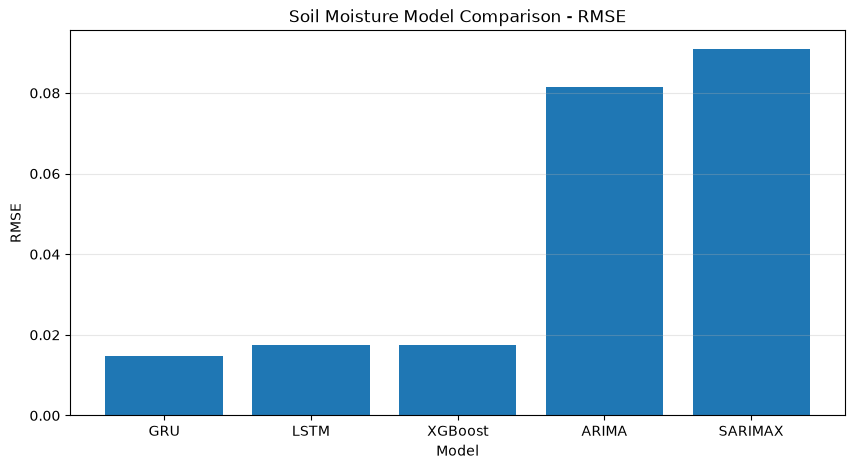

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title(
    "Soil Moisture Model Comparison - RMSE"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [41]:
predictions = {

    "ARIMA": arima_pred,

    "SARIMAX": sarimax_pred,

    "XGBoost": xgb_pred,

    "LSTM": lstm_pred,

    "GRU": gru_pred
}

In [42]:
best_prediction = predictions[
    best_model_name
]

print(
    "Selected model:",
    best_model_name
)

print(
    "Forecast samples:",
    len(best_prediction)
)

Selected model: GRU
Forecast samples: 280


In [43]:
if best_model_name in ["LSTM", "GRU"]:

    actual_best = lstm_actual

else:

    actual_best = test[:len(best_prediction)]

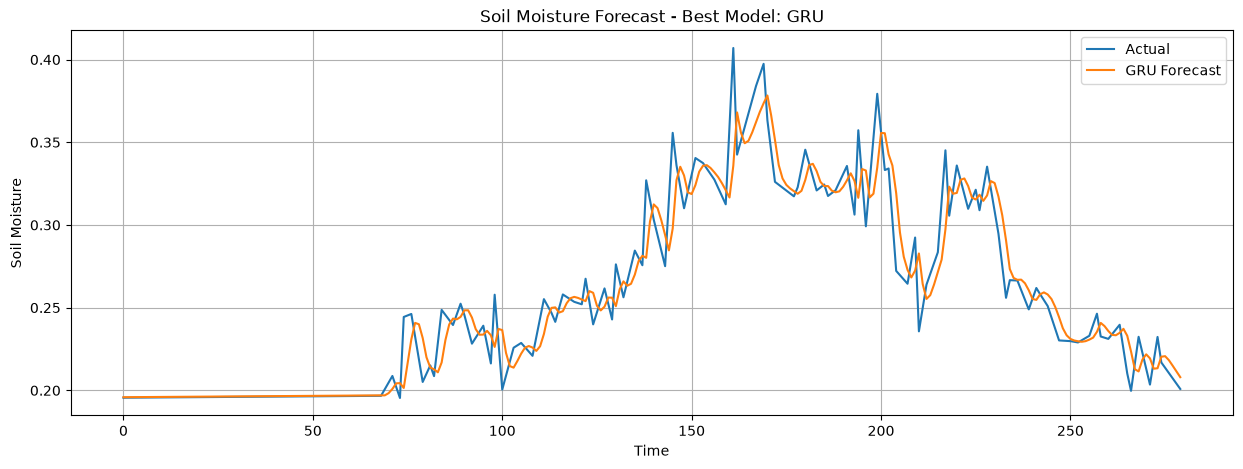

In [44]:
plt.figure(figsize=(15, 5))

plt.plot(
    actual_best,
    label="Actual"
)

plt.plot(
    best_prediction,
    label=f"{best_model_name} Forecast"
)

plt.title(
    f"Soil Moisture Forecast - Best Model: {best_model_name}"
)

plt.xlabel("Time")
plt.ylabel("Soil Moisture")

plt.legend()
plt.grid(True)

plt.show()

In [45]:
historical_min = df_daily[
    "soil_moisture"
].min()

historical_max = df_daily[
    "soil_moisture"
].max()

In [46]:
def calculate_soil_moisture_risk(
    soil_moisture,
    min_value,
    max_value
):

    if max_value == min_value:
        return 0.0

    risk = (
        soil_moisture - min_value
    ) / (
        max_value - min_value
    )

    return np.clip(
        risk,
        0,
        1
    )

In [47]:
soil_moisture_risk = np.array([

    calculate_soil_moisture_risk(
        value,
        historical_min,
        historical_max
    )

    for value in best_prediction

])

In [48]:
risk_df = pd.DataFrame({

    "Forecast_Soil_Moisture":
        best_prediction,

    "Soil_Moisture_Risk":
        soil_moisture_risk

})

display(
    risk_df.head(20)
)

,Forecast_Soil_Moisture,Soil_Moisture_Risk
0,0.195870,0.168330
1,0.195886,0.168374
2,0.195905,0.168424
3,0.195923,0.168470
4,0.195939,0.168512
5,0.195954,0.168553
6,0.195969,0.168592
7,0.195986,0.168638
8,0.196003,0.168682
9,0.196017,0.168720


In [49]:
def risk_level(score):

    if score < 0.20:
        return "LOW"

    elif score < 0.40:
        return "MODERATE"

    elif score < 0.60:
        return "HIGH"

    elif score < 0.80:
        return "VERY HIGH"

    else:
        return "EXTREME"

In [50]:
risk_df["Risk_Level"] = (
    risk_df["Soil_Moisture_Risk"]
    .apply(risk_level)
)

display(
    risk_df.head(20)
)

,Forecast_Soil_Moisture,Soil_Moisture_Risk,Risk_Level
0,0.195870,0.168330,LOW
1,0.195886,0.168374,LOW
2,0.195905,0.168424,LOW
3,0.195923,0.168470,LOW
4,0.195939,0.168512,LOW
5,0.195954,0.168553,LOW
6,0.195969,0.168592,LOW
7,0.195986,0.168638,LOW
8,0.196003,0.168682,LOW
9,0.196017,0.168720,LOW


In [51]:
current_soil_moisture_risk = float(
    np.max(soil_moisture_risk)
)

current_risk_level = risk_level(
    current_soil_moisture_risk
)

print(
    "===================================="
)

print(
    f"Best Model       : {best_model_name}"
)

print(
    f"Soil Moisture Risk Score : "
    f"{current_soil_moisture_risk:.4f}"
)

print(
    f"Risk Level       : "
    f"{current_risk_level}"
)

print(
    "===================================="
)

Best Model       : GRU
Soil Moisture Risk Score : 0.6505
Risk Level       : VERY HIGH


In [52]:
max_risk_index = np.argmax(
    soil_moisture_risk
)

max_risk_soil = best_prediction[
    max_risk_index
]

max_risk_score = soil_moisture_risk[
    max_risk_index
]

print(
    "Maximum forecasted soil moisture:",
    max_risk_soil
)

print(
    "Maximum soil moisture risk score:",
    max_risk_score
)

print(
    "Risk level:",
    risk_level(max_risk_score)
)

Maximum forecasted soil moisture: 0.3782943
Maximum soil moisture risk score: 0.6504843834032384
Risk level: VERY HIGH


In [53]:
soil_moisture_output = {

    "best_model": best_model_name,

    "risk_score": round(
        current_soil_moisture_risk,
        4
    ),

    "risk_level": current_risk_level,

    "forecast_max_soil_moisture": round(
        float(max_risk_soil),
        4
    )
}

print(soil_moisture_output)

{'best_model': 'GRU', 'risk_score': 0.6505, 'risk_level': 'VERY HIGH', 'forecast_max_soil_moisture': 0.3783}


In [54]:
import os
import torch

MODEL_DIR = r"E:\MY projects\Flash Flood Prediction Project\models"

os.makedirs(MODEL_DIR, exist_ok=True)

torch.save({
    "model_type": "LSTM",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "sequence_length": 30,
    "model_state_dict": lstm_model.state_dict()
}, os.path.join(MODEL_DIR, "lstm_model.pt"))

print("LSTM model saved successfully!")

LSTM model saved successfully!


In [55]:
torch.save({
    "model_type": "GRU",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "sequence_length": 30,
    "model_state_dict": gru_model.state_dict()
}, os.path.join(MODEL_DIR, "gru_model.pt"))

print("GRU model saved successfully!")

GRU model saved successfully!


In [1]:
# ============================================================
# SOIL MOISTURE — TRAIN + SAVE MODEL + SAVE SCALER
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = r"E:\MY projects\Flash Flood Prediction Project"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "soil_moisture_monthly"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "Soil_Moisture"
)

os.makedirs(MODEL_DIR, exist_ok=True)


# ============================================================
# 2. FIND CSV FILES
# ============================================================

csv_files = glob.glob(
    os.path.join(
        DATA_DIR,
        "**",
        "*.csv"
    ),
    recursive=True
)

print("=" * 70)
print("SOIL MOISTURE TRAINING")
print("=" * 70)

print("\nCSV files found:", len(csv_files))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found in:\n{DATA_DIR}"
    )


# ============================================================
# 3. LOAD DATA
# ============================================================

dataframes = []

for file in csv_files:

    try:

        temp = pd.read_csv(file)

        if (
            "datetime" in temp.columns
            and
            "soil_moisture" in temp.columns
        ):

            temp = temp[
                [
                    "datetime",
                    "soil_moisture"
                ]
            ]

            dataframes.append(temp)

    except Exception as e:

        print(
            "Error reading:",
            file,
            e
        )


if len(dataframes) == 0:
    raise ValueError(
        "No valid soil moisture CSV files found."
    )


df = pd.concat(
    dataframes,
    ignore_index=True
)

print(
    "\nCombined dataset shape:",
    df.shape
)


# ============================================================
# 4. CLEAN DATA
# ============================================================

df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce"
)

df["soil_moisture"] = pd.to_numeric(
    df["soil_moisture"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "datetime",
        "soil_moisture"
    ]
)

df = df.sort_values(
    "datetime"
)

# Remove duplicate timestamps
df = df.drop_duplicates(
    subset=["datetime"]
)

print(
    "Cleaned dataset shape:",
    df.shape
)


# ============================================================
# 5. CREATE DAILY DATA
# ============================================================

daily_df = (
    df
    .set_index("datetime")
    .resample("D")["soil_moisture"]
    .mean()
    .interpolate(method="time")
    .ffill()
    .bfill()
    .reset_index()
)


print(
    "\nDaily dataset shape:",
    daily_df.shape
)

print(
    daily_df.head()
)


# ============================================================
# 6. GET VALUES
# ============================================================

values = daily_df[
    "soil_moisture"
].values.astype(np.float32)


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

split_index = int(
    len(values) * 0.80
)

train_values = values[
    :split_index
]

test_values = values[
    split_index:
]

print(
    "\nTraining values:",
    len(train_values)
)

print(
    "Testing values:",
    len(test_values)
)


# ============================================================
# 8. CREATE STANDARD SCALER
# ============================================================

scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train_values.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_values.reshape(-1, 1)
)


print("\nScaler created")

print(
    "Scaler mean:",
    scaler.mean_
)

print(
    "Scaler scale:",
    scaler.scale_
)


# ============================================================
# 9. CREATE SEQUENCES
# ============================================================

SEQUENCE_LENGTH = 30


def create_sequences(
    data,
    sequence_length
):

    X = []
    y = []

    for i in range(
        sequence_length,
        len(data)
    ):

        X.append(
            data[
                i-sequence_length:i
            ]
        )

        y.append(
            data[i]
        )

    return (
        np.array(X),
        np.array(y)
    )


X_train, y_train = create_sequences(
    train_scaled,
    SEQUENCE_LENGTH
)

X_test, y_test = create_sequences(
    test_scaled,
    SEQUENCE_LENGTH
)


print("\nSequence shapes")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)


# ============================================================
# 10. BUILD GRU MODEL
# ============================================================

model = Sequential([

    GRU(
        64,
        return_sequences=True,
        input_shape=(
            SEQUENCE_LENGTH,
            1
        )
    ),

    Dropout(0.2),

    GRU(
        32
    ),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )
])


# ============================================================
# 11. COMPILE
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        "mae"
    ]
)


print("\nModel created")


# ============================================================
# 12. CALLBACKS
# ============================================================

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6
)


# ============================================================
# 13. TRAIN
# ============================================================

print("\nStarting training...")

history = model.fit(

    X_train,

    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)


# ============================================================
# 14. TEST PREDICTION
# ============================================================

y_pred_scaled = model.predict(
    X_test,
    verbose=0
)


# ============================================================
# 15. CONVERT BACK TO ORIGINAL SCALE
# ============================================================

y_test_original = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()

y_pred_original = scaler.inverse_transform(
    y_pred_scaled
).flatten()


# ============================================================
# 16. EVALUATION
# ============================================================

rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_original
    )
)

mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

r2 = r2_score(
    y_test_original,
    y_pred_original
)


print("\n" + "=" * 70)
print("SOIL MOISTURE GRU RESULTS")
print("=" * 70)

print(
    "RMSE:",
    rmse
)

print(
    "MAE :",
    mae
)

print(
    "R2  :",
    r2
)


# ============================================================
# 17. SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "soil_moisture_gru.keras"
)

model.save(
    MODEL_PATH
)


# ============================================================
# 18. SAVE SCALER
# ============================================================

SCALER_PATH = os.path.join(
    MODEL_DIR,
    "soil_moisture_scaler.pkl"
)

joblib.dump(
    scaler,
    SCALER_PATH
)


# ============================================================
# 19. SAVE DAILY DATA
# ============================================================

DAILY_DATA_PATH = os.path.join(
    MODEL_DIR,
    "soil_moisture_daily_training.csv"
)

daily_df.to_csv(
    DAILY_DATA_PATH,
    index=False
)


# ============================================================
# 20. FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "\n✅ Model:"
)

print(
    MODEL_PATH
)

print(
    "\n✅ Scaler:"
)

print(
    SCALER_PATH
)

print(
    "\n✅ Daily training data:"
)

print(
    DAILY_DATA_PATH
)

print("\nFile existence:")

print(
    "Model  :",
    os.path.exists(MODEL_PATH)
)

print(
    "Scaler :",
    os.path.exists(SCALER_PATH)
)

print(
    "Dataset:",
    os.path.exists(DAILY_DATA_PATH)
)

print("\n🎉 Soil moisture model + scaler saved successfully!")

SOIL MOISTURE TRAINING

CSV files found: 80
Error reading: E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly\soil_moisture_monthly\soil_moisture_2020_12.csv No columns to parse from file
Error reading: E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly\soil_moisture_monthly\soil_moisture_2021_01.csv No columns to parse from file
Error reading: E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly\soil_moisture_monthly\soil_moisture_2021_02.csv No columns to parse from file
Error reading: E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly\soil_moisture_monthly\soil_moisture_2021_03.csv No columns to parse from file
Error reading: E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly\soil_moisture_monthly\soil_moisture_2022_01.csv No columns to parse from file
Error reading: E:\MY projects\Flash Flood Prediction Project\data\soil_moisture_monthly\soil_moisture_monthly\soil_moisture_20

C:\Users\HP\miniconda3\envs\pytorch_gpu\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Model created

Starting training...
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.2494 - mae: 0.3578 - val_loss: 0.1140 - val_mae: 0.2255 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1353 - mae: 0.2536 - val_loss: 0.1038 - val_mae: 0.1969 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1189 - mae: 0.2335 - val_loss: 0.0677 - val_mae: 0.1588 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1129 - mae: 0.2316 - val_loss: 0.0607 - val_mae: 0.1475 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1016 - mae: 0.2202 - val_loss: 0.0745 - val_mae: 0.1793 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0961 - mae: 0.2166 - val_loss: 0.0759 - val_mae: 0.1675 - learning_rate: 0.0010
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0961 - mae: 0.2087 - val_loss: 0.0522 - val_mae: